<div style="background-color:#e6f2ff; padding:20px; border-radius:10px;">
<img style="float:left; margin-right:20px;" src='Figures/alinco.png' width="120"/>
<h1 style="color:#000047;">Actividad 1: Implementación de un modelo por Random Forest</h1>
<br style="clear:both"/>
</div>

<div style="border-left:4px solid #000047; padding:10px; margin-top:10px; background:#f5f5f5;">
<b>Objetivo:</b> En esta actividad construiras un clasificadore basados en **Random Forest** para predecir la **aceptabilidad/seguridad de un automóvil**.
</div>

<div style="margin-top:10px;">
<b>Instrucciones generales:</b>
<ul>
<li>Entrenar dos modelos (con pocos y con muchos árboles) para observar cómo mejora la exactitud, demostrar el proceso de **selección de características** basado en la importancia de variables, y reconstruir el modelo con las variables más relevantes. </li>

</ul>
</div>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Random Forest** (bosque aleatorio) es un algoritmo de **aprendizaje supervisado** basado en **ensamble** (*ensemble learning*). Tiene dos variantes: una para **clasificación** y otra para **regresión**. Es uno de los algoritmos más flexibles y fáciles de usar.

Construye **múltiples árboles de decisión** sobre distintas muestras de los datos, obtiene la predicción de cada árbol y selecciona la mejor solución mediante **votación**. Además, es un excelente indicador de la **importancia de las variables**.

> Al combinar muchos árboles se forma un "bosque"; de ahí el nombre **Random Forest**. Cuantos **más árboles**, mayor suele ser la exactitud (hasta estabilizarse).

#### Selección de características con Random Forest

El Random Forest permite **ordenar la importancia** de las variables. Durante el entrenamiento, se registra el **error out-of-bag (OOB)** y se promedia sobre el bosque.

Para medir la importancia de la característica *j*, se **permutan** sus valores en los datos y se recalcula el error OOB sobre ese conjunto perturbado. La **importancia** es la diferencia promedio de error OOB antes y después de la permutación, normalizada por su desviación estándar.

Las características que producen valores **grandes** de esta puntuación son más importantes. Con base en ella, conservaremos las más relevantes y descartaremos las menos útiles.

**Planteamiento del problema**

El objetivo es **predecir la aceptabilidad/seguridad de un automóvil** con un clasificador Random Forest en Python y scikit-learn, usando el [**Car Evaluation Data Set**](http://archive.ics.uci.edu/ml/datasets/Car+Evaluation) de la UCI.

El **Car Evaluation Data Set** relaciona la evaluación del automóvil (`class`) con **seis atributos de entrada**:

| Variable | Descripción | Valores |
|---|---|---|
| `buying` | Precio de compra | vhigh, high, med, low |
| `maint` | Costo de mantenimiento | vhigh, high, med, low |
| `doors` | Número de puertas | 2, 3, 4, 5more |
| `persons` | Capacidad de personas | 2, 4, more |
| `lug_boot` | Tamaño de la cajuela | small, med, big |
| `safety` | Seguridad estimada | low, med, high |
| `class` | **Objetivo:** evaluación | unacc, acc, good, vgood |

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [3]:
# Dataset real de la UCI (se descarga al vuelo)
#url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data'
#df = pd.read_csv(url, header=None)
# Alternativa local: df = pd.read_csv('C:/datasets/car.data', header=None)

df = pd.read_csv('car.data', header=None)

## 1.- Análisis exploratorio de datos

In [4]:
# Primeras filas (columnas aún sin nombre)
df.head()

,0,1,2,3,4,5,6
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [5]:
col_names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
df.columns = col_names
df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [7]:
# Distribución de frecuencias
for col in col_names:
    print(df[col].value_counts())
    print('=' * 40)

buying
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64
maint
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64
doors
2        432
3        432
4        432
5more    432
Name: count, dtype: int64
persons
2       576
4       576
more    576
Name: count, dtype: int64
lug_boot
small    576
med      576
big      576
Name: count, dtype: int64
safety
low     576
med     576
high    576
Name: count, dtype: int64
class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64


### Variable objetivo `class` y valores faltantes
La variable objetivo es **ordinal** (unacc < acc < good < vgood).

In [8]:
#La variable 'class' y sus categorías
df['class'].value_counts()

,count
class,
unacc,1210
acc,384
good,69
vgood,65


In [9]:
faltante = df.isnull().sum()
print(f"Total de valores nulos: ,{faltante}")

Total de valores nulos: ,buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64


## 2. Definir variables predictoras y objetivo

In [10]:
#Variable Objetivo
y = df['class']

#Variables Predictoras [todas excepto 'class']
X = df.drop(['class'], axis=1)

## 3. Dividir en entrenamiento y prueba

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Entrenamiento:', X_train.shape, '| Test:', X_test.shape)

Entrenamiento: (1382, 6) | Test: (346, 6)


## 4. Ingeniería de características (codificación)

Todas las variables son **categóricas ordinales**; las convertimos a números con `OrdinalEncoder` de scikit-learn (sin dependencias externas).

In [14]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder()
X_train = pd.DataFrame(encoder.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test = pd.DataFrame(encoder.transform(X_test), columns=X.columns, index=X_test.index)

X_train.head()

,buying,maint,doors,persons,lug_boot,safety
107,3.0,3.0,3.0,2.0,0.0,0.0
901,2.0,3.0,1.0,1.0,2.0,2.0
1709,1.0,1.0,3.0,0.0,0.0,0.0
706,0.0,2.0,2.0,0.0,1.0,2.0
678,0.0,2.0,1.0,0.0,1.0,1.0


In [15]:
X_test.head()

,buying,maint,doors,persons,lug_boot,safety
599,0.0,0.0,2.0,0.0,1.0,0.0
1201,2.0,1.0,0.0,1.0,1.0,2.0
628,0.0,0.0,3.0,0.0,0.0,2.0
1498,1.0,0.0,3.0,1.0,1.0,2.0
1263,2.0,1.0,2.0,2.0,1.0,1.0


## 5. Random Forest con pocos árboles (modelo 1)

Entrena un bosque con **10 árboles** para tener una referencia.


In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

#Árbol de referencia
#tree = DecisionTreeClassifier(random_state=0).fit(X_train, y_train)

# Modelo 1: Random Forest con 10 Árboles con OOB score activado
rf_mod1 = RandomForestClassifier(
    n_estimators=10, max_features='sqrt', oob_score=True,
    random_state=42, n_jobs=-1,
).fit(X_train, y_train)

print('Random Forest con 10 Árboles -> test accuracy:', round(accuracy_score(y_test, rf_mod1.predict(X_test))*100, 1))
print('Random Forest con 10 Árboles -> OOB score   :', round((rf_mod1.oob_score_)*100, 1))

Random Forest con 10 Árboles -> test accuracy: 94.5
Random Forest con 10 Árboles -> OOB score   : 89.9


In [17]:
y_pred = rf_mod1.predict(X_train)

In [18]:
y_pred

array(['unacc', 'unacc', 'unacc', ..., 'acc', 'unacc', 'acc'],
      dtype=object)

## 6. Random Forest con muchos arboles `n_estimators=100`

Entrena un modelo con **100 árboles** y comenta lo que puedas observar.

In [19]:
# Modelo 2: Random Forest con 100 Árboles con OOB score activado
rf_mod2 = RandomForestClassifier(
    n_estimators=100, max_features='sqrt', oob_score=True,
    random_state=10, n_jobs=-1,
).fit(X_train, y_train)

print('Random Forest con 100 Árboles -> test accuracy:', round(accuracy_score(y_test, rf_mod2.predict(X_test))*100, 1))
print('Random Forest con 100 Árboles -> OOB score   :', round((rf_mod2.oob_score_)*100, 1))

Random Forest con 100 Árboles -> test accuracy: 96.2
Random Forest con 100 Árboles -> OOB score   : 97.5


In [20]:
y_pred = rf_mod2.predict(X_test)

In [21]:
y_pred

array(['unacc', 'unacc', 'unacc', 'acc', 'unacc', 'acc', 'unacc', 'unacc',
       'unacc', 'unacc', 'vgood', 'good', 'unacc', 'unacc', 'unacc',
       'unacc', 'unacc', 'unacc', 'unacc', 'acc', 'unacc', 'acc', 'acc',
       'unacc', 'acc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'acc',
       'unacc', 'unacc', 'unacc', 'acc', 'acc', 'good', 'unacc', 'unacc',
       'unacc', 'unacc', 'unacc', 'acc', 'acc', 'good', 'acc', 'unacc',
       'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'acc', 'unacc',
       'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'good', 'unacc',
       'acc', 'unacc', 'unacc', 'acc', 'vgood', 'unacc', 'acc', 'acc',
       'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'good', 'vgood',
       'unacc', 'unacc', 'unacc', 'unacc', 'vgood', 'unacc', 'unacc',
       'acc', 'vgood', 'acc', 'unacc', 'acc', 'vgood', 'acc', 'unacc',
       'good', 'unacc', 'unacc', 'unacc', 'good', 'unacc', 'unacc',
       'unacc', 'acc', 'unacc', 'unacc', 'unacc', 'unacc', 'good', 'good',
 

#### Comentarios
Se mantienen todos los parametros a excepción de n_estimator (número de árboles), en el Modelo 1 son 10 árboles y en el Modelo 2 son 100 árboles.

* Modelo 1--> 10  árboles: 94.5% Test Accuracy (exactitud)
* Modelo 2--> 100 árboles: 96.2% Test Accuracy (exactitud)
Diferencia a favor del modelo 2 con +1.7%, indicando un mejoramiento en la exactitud.

* Modelo 1--> 10  árboles: 89.9% OOB score
* Modelo 2--> 100 árboles: 97.5% OOB score
Diferencia a favor del modelo 2 con +7.6%, indicando reducción en las variaciones de cada árbol quedando a 2.5% de una estabilidad al 100%.

Con ello, el modelo2 es más preciso y estable, muestra un mejor desempeño. Aunque se podría decir que es ligeramente mejor, porque el entrenamiento es considerable con incremento de 10 veces.


## 7. Importancia de las características

Usa el atributo `feature_importances_` del bosque para ordenar las variables por relevancia.

In [22]:
# Importancia de variables del bosque con 10 Árboles, Modelo 1
imp_var1 = (pd.Series(rf_mod1.feature_importances_, index=X.columns).sort_values(ascending=False)*100).round(1)
print('\nMODELO 1 --> Importancia de Variables Ordenadas, según su relevancia:\n', imp_var1)
print('\nSuma de Importancias:', round(imp_var1.sum(),1),'%')


MODELO 1 --> Importancia de Variables Ordenadas, según su relevancia:
 safety      26.3
persons     21.7
buying      20.1
maint       17.8
lug_boot     7.5
doors        6.7
dtype: float64

Suma de Importancias: 100.1 %


In [23]:
# Importancia de variables del bosque con 100 Árboles, Modelo 2
imp_var2 = (pd.Series(rf_mod2.feature_importances_, index=X.columns).sort_values(ascending=False)*100).round(1)
print('\nMODELO 2 --> Importancia de Variables Ordenadas, según su relevancia:\n', imp_var2)
print('\nSuma de Importancias:', round(imp_var2.sum(),1),'%')


MODELO 2 --> Importancia de Variables Ordenadas, según su relevancia:
 safety      27.3
persons     22.9
buying      19.9
maint       14.9
lug_boot     8.4
doors        6.6
dtype: float64

Suma de Importancias: 100.0 %


## 8. Visualizar la importancia de las características

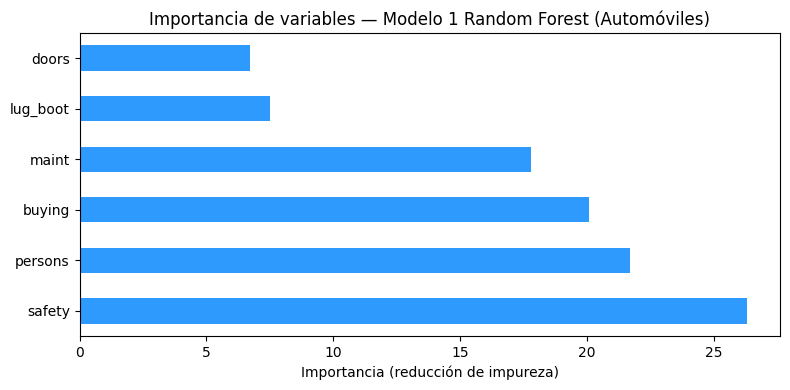

In [37]:
plt.figure(figsize=(8, 4))
imp_var1.plot.barh(color='#2E9AFE')
plt.xlabel('Importancia (reducción de impureza)')
plt.title('Importancia de variables — Modelo 1 Random Forest (Automóviles)')
plt.tight_layout()
plt.show()

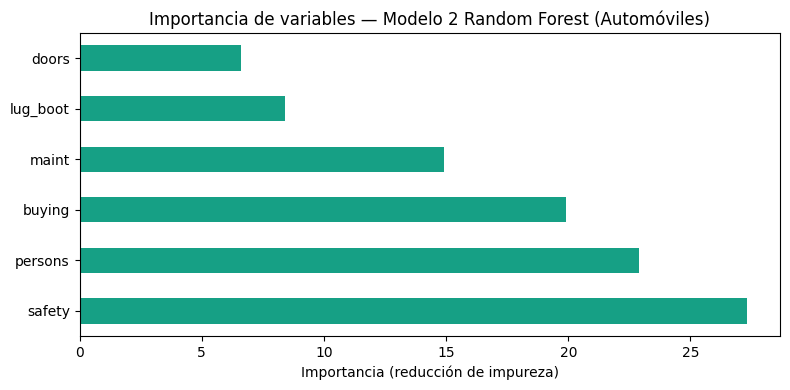

In [43]:
plt.figure(figsize=(8, 4))
imp_var2.plot.barh(color='#16a085')
plt.xlabel('Importancia (reducción de impureza)')
plt.title('Importancia de variables — Modelo 2 Random Forest (Automóviles)')
plt.tight_layout()
plt.show()

## 9. Reconstruir el modelo con las características seleccionadas

Elimina la variable **menos importante**, reconstruye el modelo y compara la exactitud.

In [25]:
#La variable menos importante es 'doors' con tan solo 6.6% de relevancia

In [26]:
X_var_elim = X.drop(['doors'], axis=1)

In [27]:
# Nuevo conjunto de variables sin 'doors'
print(X_var_elim.columns)

Index(['buying', 'maint', 'persons', 'lug_boot', 'safety'], dtype='object')


In [29]:
#Vuelvo a dividir las variables para entrenamiento y prueba,
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(X_var_elim, y, test_size=0.2, random_state=42)
print('Entrenamiento:', X_train_e.shape, '| Test:', X_test_e.shape)

X_train_e.head()

Entrenamiento: (1382, 5) | Test: (346, 5)


,buying,maint,persons,lug_boot,safety
107,vhigh,vhigh,more,big,high
901,med,vhigh,4,small,med
1709,low,low,2,big,high
706,high,med,2,med,med
678,high,med,2,med,low


In [30]:
#Utilizamos el OrdinalEncord
encoder = OrdinalEncoder()
X_train_e = pd.DataFrame(encoder.fit_transform(X_train_e), columns=X_var_elim.columns, index=X_train_e.index)
X_test_e = pd.DataFrame(encoder.transform(X_test_e), columns=X_var_elim.columns, index=X_test_e.index)

X_train_e.head()

,buying,maint,persons,lug_boot,safety
107,3.0,3.0,2.0,0.0,0.0
901,2.0,3.0,1.0,2.0,2.0
1709,1.0,1.0,0.0,0.0,0.0
706,0.0,2.0,0.0,1.0,2.0
678,0.0,2.0,0.0,1.0,1.0


In [31]:
# Utilizamos el Modelo 2
# Modelo 3: Random Forest con 100 Árboles con OOB score activado (sin la variable 'doors')
rf_mod3 = RandomForestClassifier(
    n_estimators=100, max_features='sqrt', oob_score=True,
    random_state=10, n_jobs=-1,
).fit(X_train_e, y_train_e)

print('Random Forest con 100 Árboles -> test accuracy:', round(accuracy_score(y_test_e, rf_mod3.predict(X_test_e))*100, 1))
print('Random Forest con 100 Árboles -> OOB score   :', round((rf_mod3.oob_score_)*100, 1))

Random Forest con 100 Árboles -> test accuracy: 92.5
Random Forest con 100 Árboles -> OOB score   : 94.5


In [32]:
y_pred_e = rf_mod3.predict(X_test_e)

In [33]:
y_pred_e

array(['unacc', 'good', 'unacc', 'acc', 'unacc', 'unacc', 'unacc',
       'unacc', 'unacc', 'unacc', 'acc', 'good', 'acc', 'unacc', 'unacc',
       'unacc', 'unacc', 'unacc', 'unacc', 'acc', 'unacc', 'acc', 'acc',
       'unacc', 'acc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'acc',
       'unacc', 'unacc', 'unacc', 'acc', 'good', 'good', 'unacc', 'unacc',
       'unacc', 'unacc', 'unacc', 'acc', 'acc', 'good', 'acc', 'unacc',
       'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'acc', 'unacc',
       'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'good', 'unacc',
       'acc', 'unacc', 'unacc', 'unacc', 'vgood', 'unacc', 'acc', 'acc',
       'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'vgood', 'vgood',
       'unacc', 'unacc', 'unacc', 'unacc', 'vgood', 'unacc', 'unacc',
       'acc', 'good', 'acc', 'unacc', 'acc', 'vgood', 'acc', 'unacc',
       'good', 'unacc', 'unacc', 'unacc', 'good', 'unacc', 'unacc',
       'unacc', 'acc', 'unacc', 'unacc', 'unacc', 'unacc', 'good', 'good',
 


MODELO 3 --> Importancia de Variables Ordenadas, según su relevancia:
 safety      29.5
persons     22.8
buying      22.2
maint       17.2
lug_boot     8.3
dtype: float64

Suma de Importancias: 100.0 %


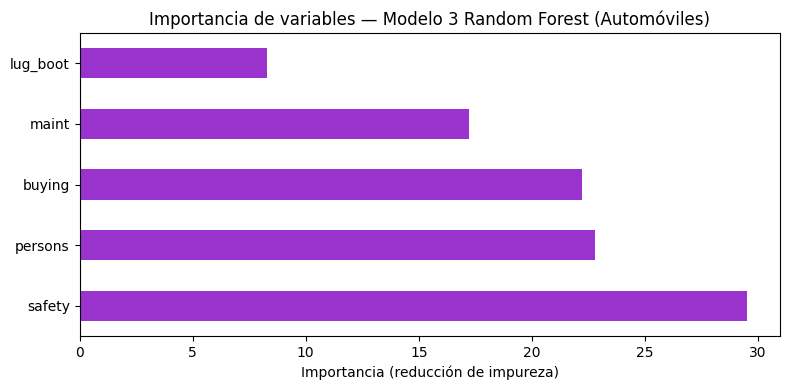

In [48]:
# Importancia de las variables del Modelo 3 del bosque con 100 Árboles
imp_var3 = (pd.Series(rf_mod3.feature_importances_, index=X_var_elim.columns).sort_values(ascending=False)*100).round(1)
print('\nMODELO 3 --> Importancia de Variables Ordenadas, según su relevancia:\n', imp_var3)
print('\nSuma de Importancias:', round(imp_var3.sum(),1),'%')

plt.figure(figsize=(8, 4))
imp_var3.plot.barh(color='#9A32CD')
plt.xlabel('Importancia (reducción de impureza)')
plt.title('Importancia de variables — Modelo 3 Random Forest (Automóviles)')
plt.tight_layout()
plt.show()

### Comentarios
Los resultados del Modelo 3 con la eliminación de la variable 'doors' que es la menos importante:

* Modelo 2 tiene seis variables, Modelo 3 tiene cinco variables.
##### Test Accuracy (exactitud)
* Modelo 2--> 100 árboles y 6 variables: 96.2%.
* Modelo 3--> 100 árboles y 5 variables: 92.5%.
Diferencia a favor del modelo 2 con +3.7%, indicando un decremento en la exactitud en el Modelo 3.

##### OOB score
* Modelo 2--> 100 árboles:97.5% OOB score
* Modelo 3--> 100 árboles: 94.5% OOB score
Diferencia a favor del modelo 2 con +3.0%, indicando mayor aumento en las variaciones de cada árbol en el Modelo 3.

Aunque se eliminó la variable menos importante o relevante 'doors' del modelo, tuvo un gran impacto en los resultados del Test y OOB score disminuyendo, por lo que se puede decir que si aporta información útil al modelo. Porque al quitar 'doors' bajo el accuracy y afecto el desempeño.

## 10. Crea un Reporte de clasificación

Muestra **precision**, **recall**, **f1-score** y **support** por clase.

### Reporte de Clasificación del Modelo 3 sin 'doors' del bosque con 100 árboles

In [36]:
from sklearn.metrics import classification_report

print(classification_report(y_test_e, y_pred_e))

              precision    recall  f1-score   support

         acc       0.96      0.78      0.86        83
        good       0.39      0.82      0.53        11
       unacc       0.98      1.00      0.99       235
       vgood       0.75      0.71      0.73        17

    accuracy                           0.92       346
   macro avg       0.77      0.83      0.78       346
weighted avg       0.94      0.92      0.93       346



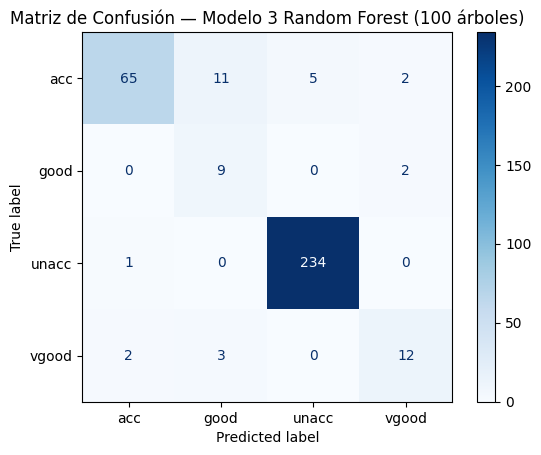

In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predicciones
y_pred_e = rf_mod3.predict(X_test_e)

# Matriz de confusión
cm = confusion_matrix(y_test_e, y_pred_e)

# Mostrar matriz
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=rf_mod3.classes_
)

disp.plot(cmap='Blues')
plt.title('Matriz de Confusión — Modelo 3 Random Forest (100 árboles)')
plt.show()

## CONCLUSIÓN
* unacc: es la categoría de 'class' mejor identificada tiene resultados superiores a 98, por lo que el modelo identifica 235 automóviles NO ACEPTABLES.
* acc: es la segunda categoría con mejor precisión pero en recall es la segunda inferior dejando el 22% no precisa si son acceptables los automóviles, sólo identifica a 83.
* good presenta el desempeño más bajo con una precisión del 39% con solo 11 casos.

De forma general, aún cuando se tiene una precisión alta de los automóviles no aceptables y de los aceptablles, se tiene muy baja la precisión cuales son buenos.